# Effect of Training Label Noise on ANLI Performance

This notebook contains the experiments used to study how synthetic training-label noise affects RoBERTa-base performance on the Adversarial Natural Language Inference (ANLI) benchmark.

The same 30,000-example training sample is evaluated under four conditions: 0%, 10%, 20%, and 30% added label noise. Each trained model is evaluated on the ANLI R1, R2, and R3 development sets.

The notebook is organized so that the experimental setup, label corruption procedure, training, evaluation, and final results can be followed from top to bottom.

## 1. Setup

First, the required libraries are installed and ANLI is loaded from Hugging Face. The dataset is then inspected before constructing the shared training sample used in all four noise conditions.

In [ ]:
!pip install -q datasets transformers evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

anli = load_dataset("facebook/anli")

README.md:   0%|          | 0.00/7.98k [00:00<?, ?B/s]

plain_text/train_r1-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.14MB            

plain_text/train_r1-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

plain_text/dev_r1-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  351kB            

plain_text/dev_r1-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating dev_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [ ]:
print(anli)

DatasetDict({
    train_r1: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 16946
    })
    dev_r1: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 1000
    })
    test_r1: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 1000
    })
    train_r2: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 45460
    })
    dev_r2: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 1000
    })
    test_r2: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 1000
    })
    train_r3: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 100459
    })
    dev_r3: Dataset({
        features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
        num_rows: 12

In [ ]:
print(anli["train_r1"][0])

{'uid': '0fd0abfb-659e-4453-b196-c3a64d2d8267', 'premise': 'The Parma trolleybus system (Italian: "Rete filoviaria di Parma" ) forms part of the public transport network of the city and "comune" of Parma, in the region of Emilia-Romagna, northern Italy. In operation since 1953, the system presently comprises four urban routes.', 'hypothesis': 'The trolleybus system has over 2 urban routes', 'label': 0, 'reason': ''}


In [ ]:
print("train_r1:", len(anli["train_r1"]))
print("train_r2:", len(anli["train_r2"]))
print("train_r3:", len(anli["train_r3"]))

train_r1: 16946
train_r2: 45460
train_r3: 100459


## 2. Create the Shared Training Sample

The three ANLI training rounds are combined, shuffled with a fixed seed, and reduced to a shared sample of 30,000 examples. The same sample is used for every noise condition so that the main experimental difference is the amount of label corruption.

In [ ]:
from datasets import concatenate_datasets

train_all = concatenate_datasets([
    anli["train_r1"],
    anli["train_r2"],
    anli["train_r3"]
])

print(train_all)

Dataset({
    features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
    num_rows: 162865
})


In [ ]:
from collections import Counter

label_counts = Counter(train_all["label"])

print("Entailment (0):", label_counts[0])
print("Neutral (1):", label_counts[1])
print("Contradiction (2):", label_counts[2])

Entailment (0): 52111
Neutral (1): 68789
Contradiction (2): 41965


In [ ]:
train_sample = train_all.shuffle(seed=42).select(range(30000))

print(train_sample)

Dataset({
    features: ['uid', 'premise', 'hypothesis', 'label', 'reason'],
    num_rows: 30000
})


In [ ]:
from collections import Counter

sample_label_counts = Counter(train_sample["label"])

print("Entailment (0):", sample_label_counts[0])
print("Neutral (1):", sample_label_counts[1])
print("Contradiction (2):", sample_label_counts[2])

Entailment (0): 9633
Neutral (1): 12729
Contradiction (2): 7638


## 3. Create the Label-Noise Conditions

To study the effect of unreliable training labels, synthetic label noise is added in a controlled way. A fixed random ordering is used so that the noisy subsets are nested: the 20% condition contains the examples already changed at 10%, and the 30% condition extends the 20% condition further.

For each selected example, the original label is replaced with one of the other two NLI labels. The premise and hypothesis remain unchanged.

In [ ]:
import random

random.seed(42)

# Create one fixed random ordering of all training-example indices
noise_order = list(range(len(train_sample)))
random.shuffle(noise_order)

# First 10% = 3,000 examples
noise_10_indices = set(noise_order[:3000])

def add_10_percent_noise(example, idx):
    if idx in noise_10_indices:
        original_label = example["label"]

        # Choose one of the two incorrect labels
        wrong_labels = [0, 1, 2]
        wrong_labels.remove(original_label)

        example["label"] = random.choice(wrong_labels)

    return example

train_noise_10 = train_sample.map(
    add_10_percent_noise,
    with_indices=True
)

print("Total examples:", len(train_noise_10))
print("Labels intentionally changed:", len(noise_10_indices))

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Total examples: 30000
Labels intentionally changed: 3000


In [ ]:
changed = sum(
    original != noisy
    for original, noisy in zip(
        train_sample["label"],
        train_noise_10["label"]
    )
)

print("Changed labels:", changed)
print("Noise percentage:", changed / len(train_sample) * 100)

Changed labels: 3000
Noise percentage: 10.0


In [ ]:
import random

# Next 10% of examples: indices 3000–5999 in our fixed noise order
additional_20_indices = noise_order[3000:6000]

# Precompute a wrong label for each new noisy example
rng = random.Random(43)

replacement_labels_20 = {}

for idx in additional_20_indices:
    original_label = train_sample[idx]["label"]
    wrong_labels = [0, 1, 2]
    wrong_labels.remove(original_label)

    replacement_labels_20[idx] = rng.choice(wrong_labels)

# Start from the existing 10% noisy dataset
def add_more_noise(example, idx):
    if idx in replacement_labels_20:
        example["label"] = replacement_labels_20[idx]
    return example

train_noise_20 = train_noise_10.map(
    add_more_noise,
    with_indices=True
)

# Verify
changed = sum(
    original != noisy
    for original, noisy in zip(
        train_sample["label"],
        train_noise_20["label"]
    )
)

print("Total examples:", len(train_noise_20))
print("Changed labels:", changed)
print("Noise percentage:", changed / len(train_sample) * 100)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Total examples: 30000
Changed labels: 6000
Noise percentage: 20.0


In [ ]:
import random

# Next 10% of examples: indices 6000–8999
additional_30_indices = noise_order[6000:9000]

rng = random.Random(44)

replacement_labels_30 = {}

for idx in additional_30_indices:
    original_label = train_sample[idx]["label"]

    wrong_labels = [0, 1, 2]
    wrong_labels.remove(original_label)

    replacement_labels_30[idx] = rng.choice(wrong_labels)

# Start from the existing 20% noisy dataset
def add_30_percent_noise(example, idx):
    if idx in replacement_labels_30:
        example["label"] = replacement_labels_30[idx]
    return example

train_noise_30 = train_noise_20.map(
    add_30_percent_noise,
    with_indices=True
)

# Verify
changed = sum(
    original != noisy
    for original, noisy in zip(
        train_sample["label"],
        train_noise_30["label"]
    )
)

print("Total examples:", len(train_noise_30))
print("Changed labels:", changed)
print("Noise percentage:", changed / len(train_sample) * 100)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Total examples: 30000
Changed labels: 9000
Noise percentage: 30.0


In [ ]:
dev_r1 = anli["dev_r1"]
dev_r2 = anli["dev_r2"]
dev_r3 = anli["dev_r3"]

print("dev_r1:", len(dev_r1))
print("dev_r2:", len(dev_r2))
print("dev_r3:", len(dev_r3))

dev_r1: 1000
dev_r2: 1000
dev_r3: 1200


## 4. Tokenization and Model Preparation

RoBERTa's tokenizer is used to encode the premise--hypothesis pairs for all training and development sets. The same preprocessing is applied to the original-label baseline and to the 10%, 20%, and 30% noise conditions so that the input representation remains consistent across experiments.

RoBERTa-base is then initialized as a three-class sequence classifier for entailment, neutral, and contradiction.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["premise"],
        example["hypothesis"],
        truncation=True
    )

In [ ]:
tokenized_train_0 = train_sample.map(
    tokenize_function,
    batched=True
)

print(tokenized_train_0)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Dataset({
    features: ['uid', 'premise', 'hypothesis', 'label', 'reason', 'input_ids', 'attention_mask'],
    num_rows: 30000
})


In [ ]:
tokenized_train_10 = train_noise_10.map(
    tokenize_function,
    batched=True
)

tokenized_train_20 = train_noise_20.map(
    tokenize_function,
    batched=True
)

tokenized_train_30 = train_noise_30.map(
    tokenize_function,
    batched=True
)

print("10%:", len(tokenized_train_10))
print("20%:", len(tokenized_train_20))
print("30%:", len(tokenized_train_30))

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

10%: 30000
20%: 30000
30%: 30000


In [ ]:
tokenized_dev_r1 = dev_r1.map(
    tokenize_function,
    batched=True
)

tokenized_dev_r2 = dev_r2.map(
    tokenize_function,
    batched=True
)

tokenized_dev_r3 = dev_r3.map(
    tokenize_function,
    batched=True
)

print("R1:", len(tokenized_dev_r1))
print("R2:", len(tokenized_dev_r2))
print("R3:", len(tokenized_dev_r3))

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

R1: 1000
R2: 1000
R3: 1200


## 5. Train the RoBERTa-base Models

A fresh RoBERTa-base sequence-classification model is trained for each noise condition. All conditions use the same training configuration: two epochs, a learning rate of 2 × 10⁻⁵, a training batch size of 8, and weight decay of 0.01.

The only intended difference between conditions is the amount of synthetic label corruption in the training data.

In [ ]:
from transformers import AutoModelForSequenceClassification

model_0 = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

print("Model loaded successfully")

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully


In [ ]:
from transformers import TrainingArguments

training_args_0 = TrainingArguments(
    output_dir="./roberta_anli_noise_0",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

print("Training settings ready")


Training settings ready


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
print(len(tokenized_train_0))

30000


In [ ]:
from transformers import DataCollatorWithPadding, Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_0 = Trainer(
    model=model_0,
    args=training_args_0,
    train_dataset=tokenized_train_0,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("Trainer ready for 0% noise model")

Trainer ready for 0% noise model


In [ ]:
train_result_0 = trainer_0.train()

Step,Training Loss
100,1.098694
200,1.091812
300,1.085235
400,1.043430
500,0.995561
600,0.894136
700,0.839849
800,0.829883
900,0.790752
1000,0.776475


Step,Training Loss
100,1.098694
200,1.091812
300,1.085235
400,1.043430
500,0.995561
600,0.894136
700,0.839849
800,0.829883
900,0.790752
1000,0.776475


In [ ]:
print(train_result_0)

TrainOutput(global_step=7500, training_loss=0.572586274210612, metrics={'train_runtime': 1484.7715, 'train_samples_per_second': 40.41, 'train_steps_per_second': 5.051, 'total_flos': 3875944312286928.0, 'train_loss': 0.572586274210612, 'epoch': 2.0})


## 6. Evaluate on ANLI R1, R2, and R3

Each trained model is evaluated on the ANLI R1, R2, and R3 development sets. Predictions are obtained from the model logits, and accuracy is calculated separately for each round.

The same evaluation procedure is used for all four noise conditions so that their performance can be compared directly.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

pred_r1_0 = trainer_0.predict(tokenized_dev_r1)

predicted_labels = np.argmax(pred_r1_0.predictions, axis=1)
true_labels = tokenized_dev_r1["label"]

accuracy_r1_0 = accuracy_score(true_labels, predicted_labels)

print("0% noise - R1 accuracy:", accuracy_r1_0)

0% noise - R1 accuracy: 0.53


In [ ]:
pred_r2_0 = trainer_0.predict(tokenized_dev_r2)

predicted_labels = np.argmax(pred_r2_0.predictions, axis=1)
true_labels = tokenized_dev_r2["label"]

accuracy_r2_0 = accuracy_score(true_labels, predicted_labels)

print("0% noise - R2 accuracy:", accuracy_r2_0)

0% noise - R2 accuracy: 0.389


In [ ]:
pred_r3_0 = trainer_0.predict(tokenized_dev_r3)

predicted_labels = np.argmax(pred_r3_0.predictions, axis=1)
true_labels = tokenized_dev_r3["label"]

accuracy_r3_0 = accuracy_score(true_labels, predicted_labels)

print("0% noise - R3 accuracy:", accuracy_r3_0)

0% noise - R3 accuracy: 0.4058333333333333


In [ ]:
from transformers import AutoModelForSequenceClassification

model_10 = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

print("10% noise model loaded")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


10% noise model loaded


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args_10 = TrainingArguments(
    output_dir="./roberta_anli_noise_10",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

trainer_10 = Trainer(
    model=model_10,
    args=training_args_10,
    train_dataset=tokenized_train_10,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("Trainer ready for 10% noise model")

Trainer ready for 10% noise model


In [ ]:
train_result_10 = trainer_10.train()

Step,Training Loss
100,1.099352
200,1.094645
300,1.095269
400,1.072819
500,1.092237
600,1.059478
700,1.046256
800,1.035928
900,1.001781
1000,1.021909


In [ ]:
print(train_result_10)

TrainOutput(global_step=7500, training_loss=0.7798466801961264, metrics={'train_runtime': 1425.5842, 'train_samples_per_second': 42.088, 'train_steps_per_second': 5.261, 'total_flos': 3875944312286928.0, 'train_loss': 0.7798466801961264, 'epoch': 2.0})


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

pred_r1_10 = trainer_10.predict(tokenized_dev_r1)

predicted_labels = np.argmax(pred_r1_10.predictions, axis=1)
true_labels = tokenized_dev_r1["label"]

accuracy_r1_10 = accuracy_score(true_labels, predicted_labels)

print("10% noise - R1 accuracy:", accuracy_r1_10)

10% noise - R1 accuracy: 0.48


In [ ]:
pred_r2_10 = trainer_10.predict(tokenized_dev_r2)

predicted_labels = np.argmax(pred_r2_10.predictions, axis=1)
true_labels = tokenized_dev_r2["label"]

accuracy_r2_10 = accuracy_score(true_labels, predicted_labels)

print("10% noise - R2 accuracy:", accuracy_r2_10)

10% noise - R2 accuracy: 0.39


In [ ]:
pred_r3_10 = trainer_10.predict(tokenized_dev_r3)

predicted_labels = np.argmax(pred_r3_10.predictions, axis=1)
true_labels = tokenized_dev_r3["label"]

accuracy_r3_10 = accuracy_score(true_labels, predicted_labels)

print("10% noise - R3 accuracy:", accuracy_r3_10)

10% noise - R3 accuracy: 0.4025


In [ ]:
from transformers import AutoModelForSequenceClassification

model_20 = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

print("20% noise model loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


20% noise model loaded


In [ ]:
tokenized_train_20 = train_noise_20.map(
    tokenize_function,
    batched=True
)

print(tokenized_train_20)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Dataset({
    features: ['uid', 'premise', 'hypothesis', 'label', 'reason', 'input_ids', 'attention_mask'],
    num_rows: 30000
})


In [ ]:
from transformers import TrainingArguments, Trainer

training_args_20 = TrainingArguments(
    output_dir="./roberta_anli_noise_20",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

trainer_20 = Trainer(
    model=model_20,
    args=training_args_20,
    train_dataset=tokenized_train_20,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("Trainer ready for 20% noise model")

Trainer ready for 20% noise model


In [ ]:
train_result_20 = trainer_20.train()

Step,Training Loss
100,1.101054
200,1.102483
300,1.091609
400,1.092242
500,1.103756
600,1.090108
700,1.093040
800,1.095471
900,1.092835
1000,1.087488


In [ ]:
print(train_result_20)

TrainOutput(global_step=7500, training_loss=1.0904570688883464, metrics={'train_runtime': 1411.7649, 'train_samples_per_second': 42.5, 'train_steps_per_second': 5.312, 'total_flos': 3875944312286928.0, 'train_loss': 1.0904570688883464, 'epoch': 2.0})


In [ ]:
pred_r1_20 = trainer_20.predict(tokenized_dev_r1)

predicted_labels = np.argmax(pred_r1_20.predictions, axis=1)
true_labels = tokenized_dev_r1["label"]

accuracy_r1_20 = accuracy_score(true_labels, predicted_labels)

print("20% noise - R1 accuracy:", accuracy_r1_20)

20% noise - R1 accuracy: 0.333


In [ ]:
pred_r2_20 = trainer_20.predict(tokenized_dev_r2)

predicted_labels = np.argmax(pred_r2_20.predictions, axis=1)
true_labels = tokenized_dev_r2["label"]

accuracy_r2_20 = accuracy_score(true_labels, predicted_labels)

print("20% noise - R2 accuracy:", accuracy_r2_20)

20% noise - R2 accuracy: 0.333


In [ ]:
pred_r3_20 = trainer_20.predict(tokenized_dev_r3)

predicted_labels = np.argmax(pred_r3_20.predictions, axis=1)
true_labels = tokenized_dev_r3["label"]

accuracy_r3_20 = accuracy_score(true_labels, predicted_labels)

print("20% noise - R3 accuracy:", accuracy_r3_20)

20% noise - R3 accuracy: 0.335


In [ ]:
from transformers import AutoModelForSequenceClassification

model_30 = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

print("30% noise model loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


30% noise model loaded


In [ ]:
tokenized_train_30 = train_noise_30.map(
    tokenize_function,
    batched=True
)

print(tokenized_train_30)

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Dataset({
    features: ['uid', 'premise', 'hypothesis', 'label', 'reason', 'input_ids', 'attention_mask'],
    num_rows: 30000
})


In [ ]:
from transformers import TrainingArguments, Trainer

training_args_30 = TrainingArguments(
    output_dir="./roberta_anli_noise_30",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

trainer_30 = Trainer(
    model=model_30,
    args=training_args_30,
    train_dataset=tokenized_train_30,
    data_collator=data_collator,
    processing_class=tokenizer
)

print("Trainer ready for 30% noise model")

Trainer ready for 30% noise model


In [ ]:
train_result_30 = trainer_30.train()

Step,Training Loss
100,1.100800
200,1.104472
300,1.095592
400,1.103282
500,1.099291
600,1.099252
700,1.099677
800,1.090617
900,1.096017
1000,1.091086


In [ ]:
import numpy as np

# Tokenize ANLI development sets
dev_r1_30 = anli["dev_r1"].map(
    tokenize_function,
    batched=True
)

dev_r2_30 = anli["dev_r2"].map(
    tokenize_function,
    batched=True
)

dev_r3_30 = anli["dev_r3"].map(
    tokenize_function,
    batched=True
)

# Run predictions
pred_r1_30 = trainer_30.predict(dev_r1_30)
pred_r2_30 = trainer_30.predict(dev_r2_30)
pred_r3_30 = trainer_30.predict(dev_r3_30)

# Calculate accuracy
def get_accuracy(pred_output):
    predictions = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids
    return (predictions == labels).mean()

acc_r1_30 = get_accuracy(pred_r1_30)
acc_r2_30 = get_accuracy(pred_r2_30)
acc_r3_30 = get_accuracy(pred_r3_30)

print("30% Noise Results")
print("-----------------")
print("R1 accuracy:", acc_r1_30)
print("R2 accuracy:", acc_r2_30)
print("R3 accuracy:", acc_r3_30)

print("\nEvaluation losses")
print("R1 loss:", pred_r1_30.metrics["test_loss"])
print("R2 loss:", pred_r2_30.metrics["test_loss"])
print("R3 loss:", pred_r3_30.metrics["test_loss"])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

30% Noise Results
-----------------
R1 accuracy: 0.333
R2 accuracy: 0.333
R3 accuracy: 0.335

Evaluation losses
R1 loss: 1.1069519519805908
R2 loss: 1.1069700717926025
R3 loss: 1.1060689687728882


## 7. Results

The final accuracies are collected for all four training conditions and compared across ANLI R1, R2, and R3.

Average accuracy decreases from about 44.2% with the original labels to 42.4% at 10% added noise. At 20% and 30% noise, performance falls to approximately one-third accuracy across all three evaluation rounds, which is close to chance level for a three-class classification task.

The following table and figure summarize the observed performance across the tested noise levels.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Noise": ["0%", "10%", "20%", "30%"],
    "R1": [0.530, 0.480, 0.333, 0.333],
    "R2": [0.389, 0.390, 0.333, 0.333],
    "R3": [0.405833, 0.4025, 0.335, 0.335]
})

results["Average"] = results[["R1", "R2", "R3"]].mean(axis=1)

print(results)

  Noise     R1     R2        R3   Average
0    0%  0.530  0.389  0.405833  0.441611
1   10%  0.480  0.390  0.402500  0.424167
2   20%  0.333  0.333  0.335000  0.333667
3   30%  0.333  0.333  0.335000  0.333667


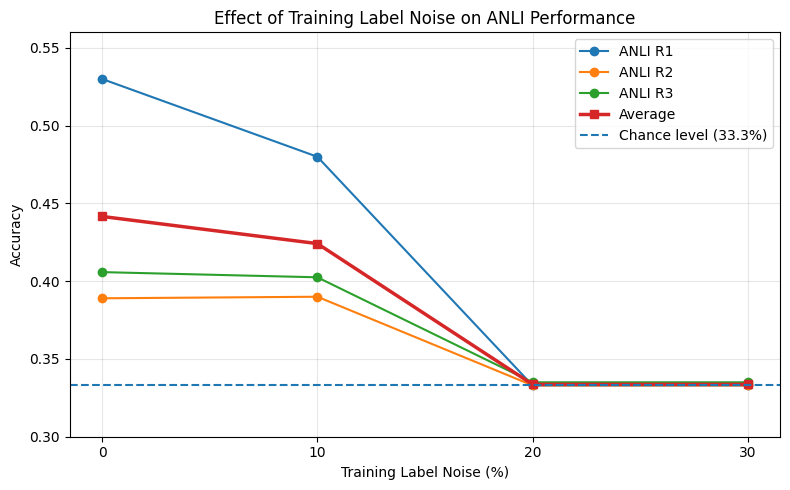

In [ ]:
import matplotlib.pyplot as plt

noise = [0, 10, 20, 30]

r1 = [0.530, 0.480, 0.333, 0.333]
r2 = [0.389, 0.390, 0.333, 0.333]
r3 = [0.405833, 0.4025, 0.335, 0.335]
average = [0.441611, 0.424167, 0.333667, 0.333667]

plt.figure(figsize=(8, 5))

plt.plot(noise, r1, marker="o", label="ANLI R1")
plt.plot(noise, r2, marker="o", label="ANLI R2")
plt.plot(noise, r3, marker="o", label="ANLI R3")
plt.plot(noise, average, marker="s", linewidth=2.5, label="Average")

# Chance level for three-class classification
plt.axhline(
    y=1/3,
    linestyle="--",
    label="Chance level (33.3%)"
)

plt.xlabel("Training Label Noise (%)")
plt.ylabel("Accuracy")
plt.title("Effect of Training Label Noise on ANLI Performance")

plt.xticks(noise)
plt.ylim(0.30, 0.56)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "anli_label_noise_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Diagnostic Check

The 30% noise condition reached approximately one-third accuracy, but this did not come from balanced guessing across the three classes.

A prediction-count diagnostic shows that the model assigned class 1 to every development example in R1, R2, and R3. This indicates a single-class prediction collapse in the 30% condition.

The same diagnostic could not be verified for the 20% condition after the runtime reset, so no equivalent claim is made for that model.

In [ ]:
from collections import Counter
import numpy as np

for name, pred_output in [
    ("R1", pred_r1_30),
    ("R2", pred_r2_30),
    ("R3", pred_r3_30)
]:
    predictions = np.argmax(pred_output.predictions, axis=-1)

    print(name)
    print("Predicted label counts:", Counter(predictions))
    print("Gold label counts:     ", Counter(pred_output.label_ids))
    print()

R1
Predicted label counts: Counter({np.int64(1): 1000})
Gold label counts:      Counter({np.int64(0): 334, np.int64(2): 333, np.int64(1): 333})

R2
Predicted label counts: Counter({np.int64(1): 1000})
Gold label counts:      Counter({np.int64(0): 334, np.int64(1): 333, np.int64(2): 333})

R3
Predicted label counts: Counter({np.int64(1): 1200})
Gold label counts:      Counter({np.int64(0): 402, np.int64(1): 402, np.int64(2): 396})



## 9. Conclusion and Limitations

Across the tested conditions, increasing training-label noise was associated with lower ANLI accuracy. The change from 0% to 10% noise was modest overall, while the 20% and 30% conditions fell to approximately chance-level performance. In the 30% condition, the model also collapsed to predicting a single class for every development example.

These results are consistent with the original hypothesis within this experimental setup, but they should be interpreted cautiously. The study uses one RoBERTa-base architecture, one 30,000-example training sample, and one reported run per noise condition. Random label corruption is also only a controlled proxy for annotation errors and does not reproduce the exact kinds of errors that may occur in ANLI.

A stronger follow-up study would repeat each condition with several random seeds and test additional noise levels, especially between 10% and 20%.



The reported results come from one training run per noise condition.
Because the experiment was not repeated across multiple independent
training seeds, exact accuracy values may vary slightly across reruns.